In [1]:
R.version.string

[1] "R version 4.6.1 (2026-06-24)"

In [2]:
install.packages("keras")
install.packages("tensorflow")
install.packages("imager")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘RcppTOML’, ‘here’, ‘png’, ‘config’, ‘tfautograph’, ‘reticulate’, ‘tensorflow’, ‘tfruns’, ‘zeallot’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘bmp’, ‘tiff’, ‘jpeg’, ‘readbitmap’, ‘downloader’, ‘igraph’




In [3]:
library(keras)
library(tensorflow)
library(imager)

The keras package is deprecated. Please use the keras3 package instead.
Alternatively, to continue using legacy keras, call `py_require_legacy_keras()`.

Loading required package: magrittr


Attaching package: ‘imager’


The following object is masked from ‘package:magrittr’:

    add


The following objects are masked from ‘package:stats’:

    convolve, spectrum


The following object is masked from ‘package:graphics’:

    frame


The following object is masked from ‘package:base’:

    save.image




In [4]:
tensorflow::tf_config()

Hint: To use tensorflow with `py_require()`, call `py_require("tensorflow")` at the start of the R session



Valid installation of TensorFlow not found.

Python environments searched for 'tensorflow' package:
 /root/.local/share/uv/python/cpython-3.12.14-linux-x86_64-gnu/bin/python3.12

Python exception encountered:
 Traceback (most recent call last):
  File "/usr/local/lib/R/site-library/reticulate/python/rpytools/loader.py", line 122, in _find_and_load_hook
    return _run_hook(name, _hook)
           ^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/R/site-library/reticulate/python/rpytools/loader.py", line 96, in _run_hook
    module = hook()
             ^^^^^^
  File "/usr/local/lib/R/site-library/reticulate/python/rpytools/loader.py", line 120, in _hook
    return _find_and_load(name, import_)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
ModuleNotFoundError: No module named 'tensorflow'


You can install TensorFlow using the install_tensorflow() function.
 

In [10]:
zip_files <- list.files(
  "/content",
  pattern = "\\.zip$",
  full.names = TRUE
)

zip_files

[1] "/content/images-20260825T161414Z-1-001.zip"

In [11]:
file_path <- zip_files[1]

file_path

[1] "/content/images-20260825T161414Z-1-001.zip"

In [12]:
unzip(file_path, exdir = "/content/")

In [13]:
list.files("/content/images")

[1] "c1.jpg" "c2.jpg" "c3.jpg" "c4.jpg" "c5.jpg" "c6.jpg" "p1.jpg" "p2.jpg"
 [9] "p3.jpg" "p4.jpg" "p5.jpg" "p6.jpg"

In [14]:
class_C <- list.files(
  "/content/images",
  pattern = "^c.*\\.jpg$",
  full.names = TRUE,
  ignore.case = TRUE
)

class_P <- list.files(
  "/content/images",
  pattern = "^p.*\\.jpg$",
  full.names = TRUE,
  ignore.case = TRUE
)

In [15]:
class_C

[1] "/content/images/c1.jpg" "/content/images/c2.jpg" "/content/images/c3.jpg"
[4] "/content/images/c4.jpg" "/content/images/c5.jpg" "/content/images/c6.jpg"

In [16]:
class_P

[1] "/content/images/p1.jpg" "/content/images/p2.jpg" "/content/images/p3.jpg"
[4] "/content/images/p4.jpg" "/content/images/p5.jpg" "/content/images/p6.jpg"

In [17]:
length(class_C)
length(class_P)

[1] 6

[1] 6

In [18]:
pics <- c(class_C, class_P)
length(pics)

[1] 12

In [19]:
mypic <- list()

for (i in 1:length(pics)) {

  mypic[[i]] <- load.image(pics[i])

}

[1] 12

[1] 308 164   1   3

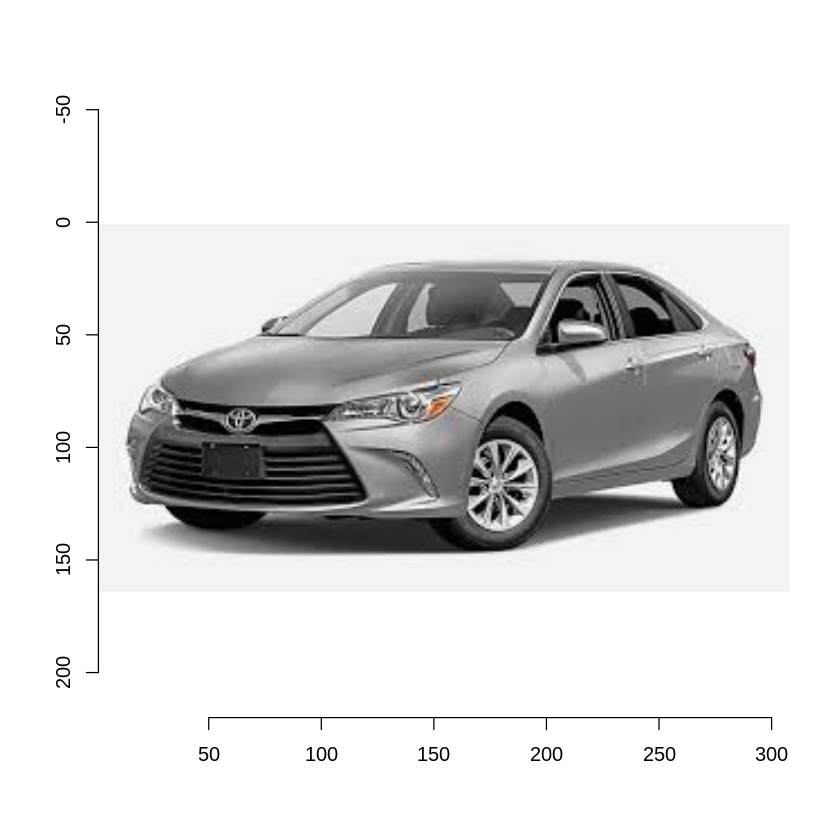

In [20]:
length(mypic)
plot(mypic[[1]])
dim(mypic[[1]])

In [22]:
for (i in 1:length(mypic)) {

  mypic[[i]] <- resize(
    mypic[[i]],
    size_x = 480,
    size_y = 480
  )

}
dim(mypic[[1]])

[1] 480 480   1   3

In [23]:
for (i in 1:length(mypic)) {

  mypic[[i]] <- as.array(mypic[[i]])

}
dim(mypic[[1]])

[1] 480 480   1   3

In [24]:
for (i in 1:length(mypic)) {

  mypic[[i]] <- as.vector(mypic[[i]])

}
length(mypic[[1]])

[1] 691200

In [25]:
image_matrix <- do.call(rbind, mypic)
dim(image_matrix)

[1]     12 691200

In [26]:
image_matrix <- image_matrix / max(image_matrix)
range(image_matrix)

[1] 0 1

In [27]:
labels <- c(
  rep(0, length(class_C)),
  rep(1, length(class_P))
)
labels

[1] 0 0 0 0 0 0 1 1 1 1 1 1

In [28]:
set.seed(123)

n <- nrow(image_matrix)

train_index <- sample(
  1:n,
  size = round(0.75 * n)
)

test_index <- setdiff(
  1:n,
  train_index
)

In [29]:
trainx <- image_matrix[train_index, ]

testx <- image_matrix[test_index, ]

In [30]:
dim(trainx)
dim(testx)

[1]      9 691200

[1]      3 691200

In [31]:
trainy <- labels[train_index]

testy <- labels[test_index]

In [32]:
trainy
testy

[1] 0 1 1 0 0 1 0 0 1

[1] 0 1 1

In [34]:
install.packages("keras3")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘dotty’




In [35]:
library(keras3)

Registered S3 methods overwritten by 'keras3':
  method                               from 
  as.data.frame.keras_training_history keras
  plot.keras_training_history          keras
  print.keras_training_history         keras
  r_to_py.R6ClassGenerator             keras


Attaching package: ‘keras3’


The following objects are masked from ‘package:tensorflow’:

    set_random_seed, shape


The following objects are masked from ‘package:keras’:

    %<-active%, %py_class%, activation_elu, activation_exponential,
    activation_gelu, activation_hard_sigmoid, activation_linear,
    activation_relu, activation_selu, activation_sigmoid,
    activation_softmax, activation_softplus, activation_softsign,
    activation_tanh, adapt, application_densenet121,
    application_densenet169, application_densenet201,
    application_efficientnet_b0, application_efficientnet_b1,
    application_efficientnet_b2, application_efficientnet_b3,
    application_efficientnet_b4, application_efficientnet_b5,


In [36]:
use_backend("tensorflow")

In [37]:
tf_version()

[1] ‘2.21’

In [38]:
library(tensorflow)

tf$constant("Hello TensorFlow!")

tf.Tensor(b'Hello TensorFlow!', shape=(), dtype=string)

In [40]:
trainLabels <- to_categorical(
  trainy,
  num_classes = 2
)

testLabels <- to_categorical(
  testy,
  num_classes = 2
)

In [41]:
trainLabels

1,0
0,1
0,1
1,0
1,0
0,1
1,0
1,0
0,1


In [42]:
model <- keras_model_sequential() %>%
  layer_dense(
    units = 512,
    activation = "relu",
    input_shape = ncol(trainx)
  ) %>%
  layer_dropout(rate = 0.1) %>%
  layer_dense(
    units = 256,
    activation = "relu"
  ) %>%
  layer_dropout(rate = 0.1) %>%
  layer_dense(
    units = 256,
    activation = "relu"
  ) %>%
  layer_dropout(rate = 0.1) %>%
  layer_dense(
    units = 2,
    activation = "softmax"
  )

In [43]:
summary(model)

Model: "sequential"
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                     │ (None, 512)              │   353,894,912 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout (Dropout)                 │ (None, 512)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_1 (Dense)                   │ (None, 256)              │       131,328 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dropout_1 (Dropout)               │ (None, 256)              │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ dense_2 (Dense)                   │ (None, 256)              │        65,792 │
├───────

In [44]:
model %>% compile(
  optimizer = optimizer_adam(),
  loss = "categorical_crossentropy",
  metrics = "accuracy"
)

In [45]:
history <- model %>% fit(
  trainx,
  trainLabels,
  epochs = 30,
  batch_size = 3,
  validation_split = 0.2
)

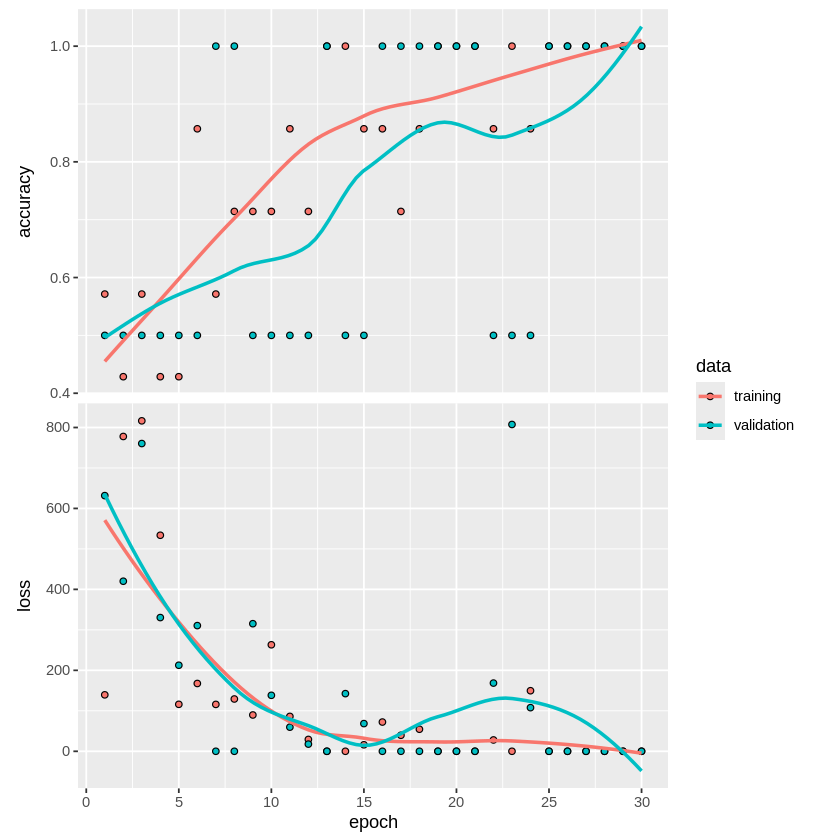

In [46]:
plot(history)

In [47]:
evaluation <- model %>% evaluate(
  testx,
  testLabels
)

evaluation

$accuracy
[1] 1

$loss
[1] 0

In [48]:
predictions <- model %>% predict(testx)

In [49]:
predictions

1,0
0,1
0,1


In [50]:
predicted_class <- apply(
  predictions,
  1,
  which.max
) - 1

In [51]:
predicted_label <- ifelse(
  predicted_class == 0,
  "C",
  "P"
)

In [52]:
actual_label <- ifelse(
  testy == 0,
  "C",
  "P"
)

In [53]:
results <- data.frame(
  Actual = actual_label,
  Predicted = predicted_label
)

results

Actual,Predicted
<chr>,<chr>
C,C
P,P
P,P


In [54]:
accuracy <- mean(
  actual_label == predicted_label
)

accuracy

[1] 1

In [55]:
conf_matrix <- table(
  Actual = actual_label,
  Predicted = predicted_label
)

conf_matrix

      Predicted
Actual C P
     C 1 0
     P 0 2

In [56]:
accuracy_C <- sum(
  actual_label == "C" & predicted_label == "C"
) / sum(actual_label == "C")

accuracy_P <- sum(
  actual_label == "P" & predicted_label == "P"
) / sum(actual_label == "P")

accuracy_C
accuracy_P

[1] 1

[1] 1

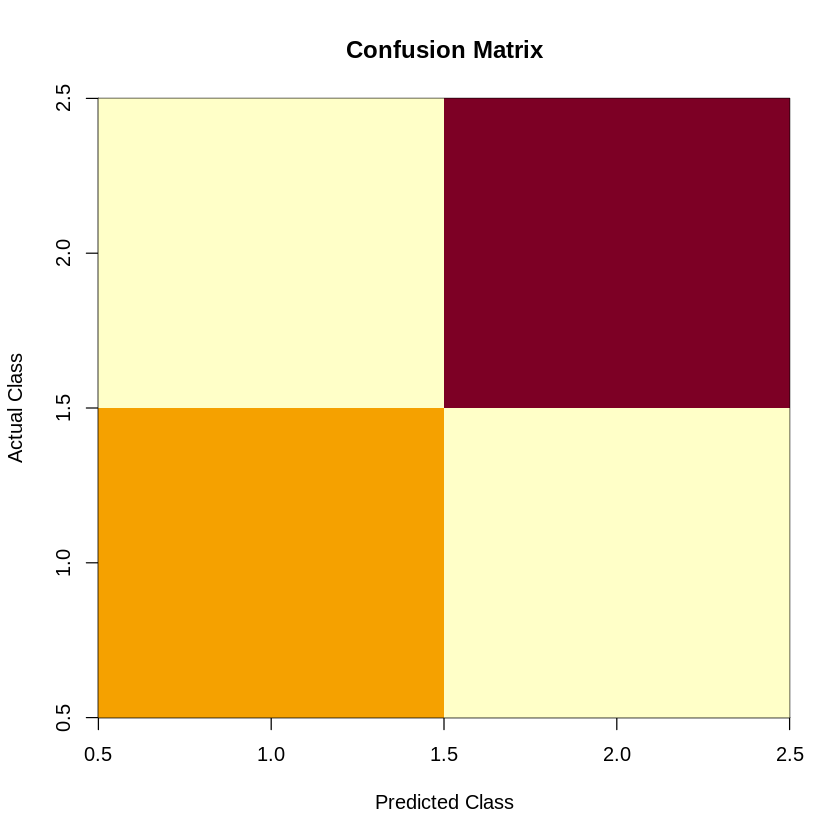

In [57]:
image(
  1:nrow(conf_matrix),
  1:ncol(conf_matrix),
  conf_matrix,
  xlab = "Predicted Class",
  ylab = "Actual Class",
  main = "Confusion Matrix"
)

In [58]:
new_image <- load.image(
  "/content/images/c1.jpg"
)

In [59]:
new_image <- resize(
  new_image,
  size_x = 480,
  size_y = 480
)

In [60]:
new_image <- as.array(new_image)
new_image <- as.vector(new_image)

In [61]:
new_image <- new_image / max(new_image)

In [62]:
new_image <- matrix(
  new_image,
  nrow = 1
)

In [63]:
new_prediction <- model %>%
  predict(new_image)

new_prediction

1,0


In [64]:
new_class <- ifelse(
  which.max(new_prediction) == 1,
  "C",
  "P"
)

new_class

[1] "C"

In [65]:
new_image <- load.image(
  "/content/images/p1.jpg"
)

new_image <- resize(
  new_image,
  size_x = 480,
  size_y = 480
)

new_image <- as.array(new_image)
new_image <- as.vector(new_image)

new_image <- new_image / max(new_image)

new_image <- matrix(
  new_image,
  nrow = 1
)

In [66]:
new_prediction <- model %>%
  predict(new_image)

new_prediction

0,1


In [67]:
new_class <- ifelse(
  which.max(new_prediction) == 1,
  "C",
  "P"
)

new_class

[1] "P"

In [70]:
conf_matrix <- table(
  Actual = actual_label,
  Predicted = predicted_label
)

print(conf_matrix)

      Predicted
Actual C P
     C 1 0
     P 0 2


In [71]:
final_results <- data.frame(
  Image = basename(pics[test_index]),
  Actual_Class = actual_label,
  Predicted_Class = predicted_label
)

final_results

Image,Actual_Class,Predicted_Class
<chr>,<chr>,<chr>
c1.jpg,C,C
p1.jpg,P,P
p2.jpg,P,P


In [72]:
probability_results <- data.frame(
  Image = basename(pics[test_index]),
  Actual = actual_label,
  Probability_C = round(predictions[,1], 4),
  Probability_P = round(predictions[,2], 4),
  Predicted = predicted_label
)

probability_results

Image,Actual,Probability_C,Probability_P,Predicted
<chr>,<chr>,<dbl>,<dbl>,<chr>
c1.jpg,C,1,0,C
p1.jpg,P,0,1,P
p2.jpg,P,0,1,P
